# CBR Diet Recommendation 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 1. Load & Cleaning df_diet

Langkah pembersihan (mengisi missing, standarisasi teks, validasi rentang numerik, hapus duplikat).

In [2]:
df_diet = pd.read_csv('diet_recommendations_dataset.csv')

# Isi missing kategorikal
df_diet['Disease_Type'] = df_diet['Disease_Type'].fillna('None')
df_diet['Dietary_Restrictions'] = df_diet['Dietary_Restrictions'].fillna('None')
df_diet['Allergies'] = df_diet['Allergies'].fillna('None')

# Standarisasi teks -> lowercase + strip
text_cols = ['Gender', 'Disease_Type', 'Severity', 'Physical_Activity_Level',
             'Dietary_Restrictions', 'Allergies', 'Preferred_Cuisine',
             'Diet_Recommendation']
for col in text_cols:
    df_diet[col] = df_diet[col].astype(str).str.strip().str.lower()

# Rename agar konsisten
df_diet.rename(columns={
    'Patient_ID': 'patient_id',
    'Cholesterol_mg/dL': 'Cholesterol',
    'Glucose_mg/dL': 'Glucose'
}, inplace=True)

# Validasi rentang fisik
df_diet = df_diet[
    (df_diet['BMI'].between(10, 80)) &
    (df_diet['Age'].between(1, 120)) &
    (df_diet['Weekly_Exercise_Hours'].between(0, 168))
]
df_diet = df_diet.drop_duplicates()

print('Shape setelah cleaning :', df_diet.shape)
print('Distribusi target Diet_Recommendation:')
print(df_diet['Diet_Recommendation'].value_counts())


Shape setelah cleaning : (1000, 20)
Distribusi target Diet_Recommendation:
Diet_Recommendation
balanced      426
low_sodium    316
low_carb      258
Name: count, dtype: int64


## 2. Seleksi & penamaan kolom (skema lowercase)

In [3]:
df_cbr = df_diet.rename(columns={
    'Age': 'age',
    'BMI': 'bmi',
    'Disease_Type': 'disease_type',
    'Cholesterol': 'cholesterol',
    'Glucose': 'glucose',
    'Blood_Pressure_mmHg': 'blood_pressure',
    'Diet_Recommendation': 'diet_recommendation',
})[['patient_id', 'age', 'bmi', 'disease_type',
    'cholesterol', 'glucose', 'blood_pressure', 'diet_recommendation']].copy()

# Pastikan numerik benar-benar numerik, isi NaN dengan median
num_check = ['age', 'bmi', 'cholesterol', 'glucose', 'blood_pressure']
for c in num_check:
    df_cbr[c] = pd.to_numeric(df_cbr[c], errors='coerce')
    df_cbr[c] = df_cbr[c].fillna(df_cbr[c].median())

print('df_cbr shape:', df_cbr.shape)
df_cbr.head()


df_cbr shape: (1000, 8)


,patient_id,age,bmi,disease_type,cholesterol,glucose,blood_pressure,diet_recommendation
0,P0001,56,22.8,obesity,173.3,116.3,133,balanced
1,P0002,69,35.4,diabetes,199.2,137.1,120,low_carb
2,P0003,46,21.2,hypertension,181.0,109.6,121,low_sodium
3,P0004,32,21.6,none,168.2,159.4,144,balanced
4,P0005,60,20.5,diabetes,200.4,182.3,172,low_carb


## 3. Definisi 6 Fitur Berbobot (CBR)

| Fitur | Bobot |
|---|---|
| disease_type | 0.30 |
| bmi | 0.20 |
| cholesterol | 0.15 |
| blood_pressure | 0.15 |
| age | 0.10 |
| glucose | 0.10 |


In [4]:
weight_config = {
    'disease_type': 0.30,
    'bmi': 0.20,
    'cholesterol': 0.15,
    'blood_pressure': 0.15,
    'age': 0.10,
    'glucose': 0.10,
}
numeric_feats = ['bmi', 'cholesterol', 'blood_pressure', 'age', 'glucose']

X = df_cbr[['disease_type'] + numeric_feats].copy()
y = df_cbr['diet_recommendation'].copy()

# One-hot disease_type (dinamis sesuai kategori yang ada)
X = pd.get_dummies(X, columns=['disease_type'], prefix='disease_type')
disease_cols = [c for c in X.columns if c.startswith('disease_type_')]
print('Kolom disease_type hasil one-hot:', disease_cols)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('\nMapping target:')
for i, c in enumerate(le.classes_):
    print(f'  {c} -> {i}')


Kolom disease_type hasil one-hot: ['disease_type_diabetes', 'disease_type_hypertension', 'disease_type_none', 'disease_type_obesity']

Mapping target:
  balanced -> 0
  low_carb -> 1
  low_sodium -> 2


## 4. Split data + scaling (fit hanya pada train → tanpa data leakage)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

X_train = X_train.copy()
X_test = X_test.copy()

# MinMax di-fit HANYA pada train
scaler = MinMaxScaler()
X_train[numeric_feats] = scaler.fit_transform(X_train[numeric_feats])
X_test[numeric_feats]  = scaler.transform(X_test[numeric_feats])

# Pastikan kolom one-hot bertipe float
X_train[disease_cols] = X_train[disease_cols].astype(float)
X_test[disease_cols]  = X_test[disease_cols].astype(float)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)


X_train: (800, 9) | X_test: (200, 9)


## 5. Vektor bobot per kolom

Bobot `disease_type` (0.30) dibagi rata ke seluruh kolom dummy disease, lalu seluruh bobot dinormalisasi agar berjumlah 1.

In [6]:
col_weights = {f: weight_config[f] for f in numeric_feats}
for c in disease_cols:
    col_weights[c] = weight_config['disease_type'] / len(disease_cols)

total = sum(col_weights.values())
col_weights = {k: v / total for k, v in col_weights.items()}

feature_order = numeric_feats + disease_cols
w_vec = np.array([col_weights[f] for f in feature_order], dtype=float)

Xtr = X_train[feature_order].to_numpy(dtype=float)
Xte = X_test[feature_order].to_numpy(dtype=float)
ytr = np.asarray(y_train)
yte = np.asarray(y_test)

print('Bobot per kolom (sudah dinormalisasi):')
for f in feature_order:
    print(f'  {f:35s}: {col_weights[f]:.4f}')


Bobot per kolom (sudah dinormalisasi):
  bmi                                : 0.2000
  cholesterol                        : 0.1500
  blood_pressure                     : 0.1500
  age                                : 0.1000
  glucose                            : 0.1000
  disease_type_diabetes              : 0.0750
  disease_type_hypertension          : 0.0750
  disease_type_none                  : 0.0750
  disease_type_obesity               : 0.0750


## 6. Multi-Attribute Hash-Based Indexing

Indexing digunakan agar sistem tidak perlu menghitung jarak ke seluruh case base.
Setiap kasus diberi **index key** dari 3 fitur, lalu disimpan dalam hash table.
Saat query baru masuk, sistem langsung mengambil kandidat dari bucket yang sesuai.

**3 fitur kunci index:**

| # | Fitur | Kategorisasi | Threshold |
|---|---|---|---|
| 1 | `disease_type` | nilai asli (diabetes, hypertension, dll.) | -- |
| 2 | `bmi` | UW / NR / OW / OB | <18.5 / 18.5-25 / 25-30 / >=30 |
| 3 | `blood_pressure` | Low / Normal / High1 / High2 | <120 / 120-130 / 130-140 / >=140 |

Contoh index key: `diabetes_OW_High1`


In [7]:
from collections import defaultdict

def bmi_category(v):
    if v < 18.5:   return 'UW'
    elif v < 25.0: return 'NR'
    elif v < 30.0: return 'OW'
    else:          return 'OB'

def bp_category(v):
    if v < 120:    return 'Low'
    elif v < 130:  return 'Normal'
    elif v < 140:  return 'High1'
    else:          return 'High2'

def build_index_key(disease, bmi_val, bp_val):
    d = str(disease).strip().lower().replace(' ', '_')
    return f"{d}_{bmi_category(bmi_val)}_{bp_category(bp_val)}"

# -- Bangun hash table dari case base (X_train) ------------------------------
train_idx = X_train.index
raw_train = df_cbr.loc[train_idx, ['disease_type', 'bmi', 'blood_pressure']].copy()

hash_table = defaultdict(list)
for enum_i, (_, row) in enumerate(raw_train.iterrows()):
    key = build_index_key(row['disease_type'], row['bmi'], row['blood_pressure'])
    hash_table[key].append(enum_i)

print(f'Hash table dibangun')
print(f'  Jumlah kasus (case base) : {len(raw_train):,}')
print(f'  Jumlah bucket unik       : {len(hash_table)}')


Hash table dibangun
  Jumlah kasus (case base) : 800
  Jumlah bucket unik       : 64


## 7. Visualisasi Struktur Index & Bobot Fitur

Menampilkan distribusi bucket hash table dan bobot tiap fitur dalam perhitungan kemiripan.


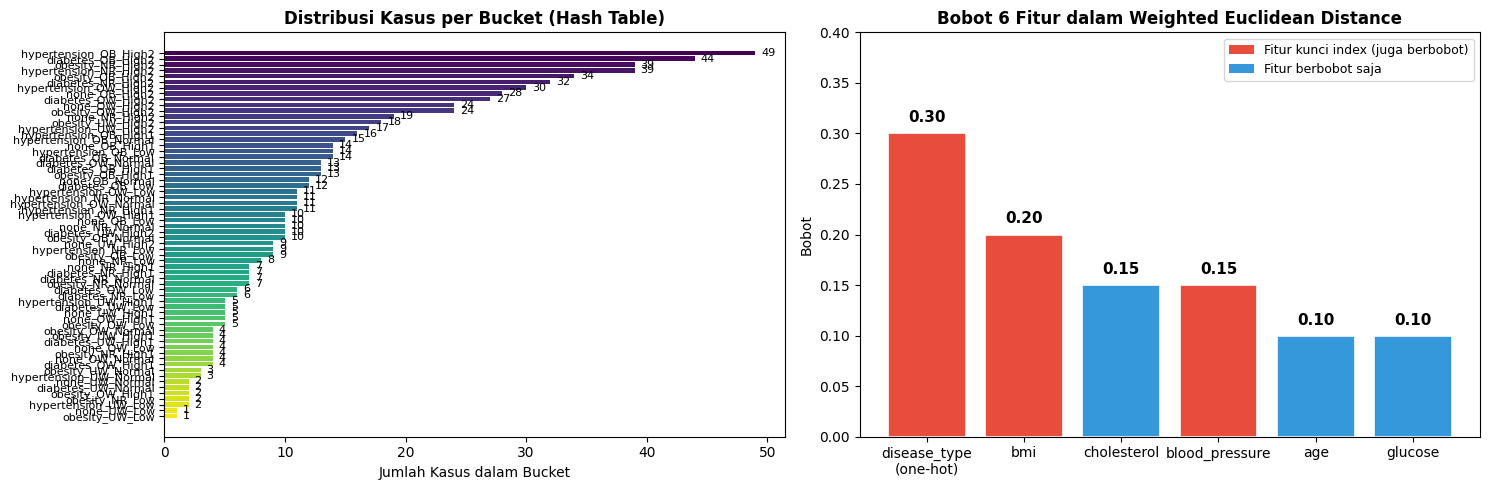


=== RINGKASAN FITUR INDEX & BOBOT ===
Fitur                  Kunci Index   Bobot   Kategorisasi
-----------------------------------------------------------------
disease_type            Ya (ke-1)     0.30   nilai asli (diabetes, dll.)
bmi                     Ya (ke-2)     0.20   UW / NR / OW / OB
cholesterol               Tidak       0.15   numerik kontinu
blood_pressure          Ya (ke-3)     0.15   Low / Normal / High1 / High2
age                       Tidak       0.10   numerik kontinu
glucose                   Tidak       0.10   numerik kontinu
-----------------------------------------------------------------
TOTAL                    3 fitur      1.00  


In [8]:
# ---- 1. Distribusi ukuran bucket -------------------------------------------
bucket_sizes = sorted([len(v) for v in hash_table.values()], reverse=True)
bucket_keys  = [k for k, _ in sorted(hash_table.items(), key=lambda x: -len(x[1]))]
bucket_vals  = [len(hash_table[k]) for k in bucket_keys]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart: ukuran tiap bucket
colors = plt.cm.viridis([i/len(bucket_keys) for i in range(len(bucket_keys))])
axes[0].barh(range(len(bucket_keys)), bucket_vals, color=colors)
axes[0].set_yticks(range(len(bucket_keys)))
axes[0].set_yticklabels(bucket_keys, fontsize=8)
axes[0].set_xlabel('Jumlah Kasus dalam Bucket')
axes[0].set_title('Distribusi Kasus per Bucket (Hash Table)', fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(bucket_vals):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=8)

# ---- 2. Bobot fitur (6 fitur berbobot, sebelum redistribusi one-hot) -------
fitur_label  = ['disease_type\n(one-hot)', 'bmi', 'cholesterol', 'blood_pressure', 'age', 'glucose']
bobot_utama  = [0.30, 0.20, 0.15, 0.15, 0.10, 0.10]
bar_colors   = ['#e74c3c' if f in ['disease_type\n(one-hot)', 'bmi', 'blood_pressure']
                else '#3498db' for f in fitur_label]

bars = axes[1].bar(fitur_label, bobot_utama, color=bar_colors, edgecolor='white', linewidth=1.2)
axes[1].set_ylabel('Bobot')
axes[1].set_title('Bobot 6 Fitur dalam Weighted Euclidean Distance', fontweight='bold')
axes[1].set_ylim(0, 0.40)
axes[1].axhline(y=0, color='black', linewidth=0.5)
for bar, val in zip(bars, bobot_utama):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Legenda warna
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Fitur kunci index (juga berbobot)'),
    Patch(facecolor='#3498db', label='Fitur berbobot saja')
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# ---- Tabel ringkasan -------------------------------------------------------
print('\n=== RINGKASAN FITUR INDEX & BOBOT ===')
print(f'{"Fitur":<22} {"Kunci Index":^12} {"Bobot":^8} {"Kategorisasi"}')
print('-' * 65)
rows_info = [
    ('disease_type',   'Ya (ke-1)', '0.30', 'nilai asli (diabetes, dll.)'),
    ('bmi',            'Ya (ke-2)', '0.20', 'UW / NR / OW / OB'),
    ('cholesterol',    'Tidak',     '0.15', 'numerik kontinu'),
    ('blood_pressure', 'Ya (ke-3)', '0.15', 'Low / Normal / High1 / High2'),
    ('age',            'Tidak',     '0.10', 'numerik kontinu'),
    ('glucose',        'Tidak',     '0.10', 'numerik kontinu'),
]
for r in rows_info:
    print(f'{r[0]:<22} {r[1]:^12} {r[2]:^8} {r[3]}')
print('-' * 65)
print(f'{"TOTAL":<22} {"3 fitur":^12} {"1.00":^8}')


## 8. Retrieval CBR -- Hash Index + Weighted Euclidean Distance

Alur untuk setiap query baru:
1. Bentuk index key dari `disease_type`, `bmi`, `blood_pressure`
2. Ambil kandidat dari bucket yang sesuai di hash table
3. Hitung Weighted Euclidean Distance **hanya ke kandidat bucket** (bukan seluruh case base)
4. Ambil k kasus terdekat -> majority vote -> rekomendasi diet


In [9]:
def predict_cbr_indexed(Xte_arr, raw_test_df, Xtr_arr, ytr_arr, w_vec, hash_table, k=5):
    preds  = []
    n_hits = []
    for q_vec, (_, q_raw) in zip(Xte_arr, raw_test_df.iterrows()):
        key = build_index_key(q_raw['disease_type'], q_raw['bmi'], q_raw['blood_pressure'])
        candidates = hash_table.get(key, [])
        if len(candidates) < k:
            candidates = list(range(len(Xtr_arr)))
        n_hits.append(len(candidates))
        cand_X = Xtr_arr[candidates]
        cand_y = ytr_arr[candidates]
        dist    = np.sqrt(np.sum(w_vec * (cand_X - q_vec) ** 2, axis=1))
        top_idx = np.argsort(dist)[:k]
        labels  = cand_y[top_idx]
        vals, counts = np.unique(labels, return_counts=True)
        top_vals = vals[counts == counts.max()]
        if len(top_vals) == 1:
            preds.append(int(top_vals[0]))
        else:
            best, best_d = None, float('inf')
            for v in top_vals:
                avg_d = dist[top_idx][labels == v].mean()
                if avg_d < best_d:
                    best, best_d = v, avg_d
            preds.append(int(best))
    avg_cand = sum(n_hits) / len(n_hits)
    pct = (1 - avg_cand / len(Xtr_arr)) * 100
    print(f'  Rata-rata kandidat per query : {avg_cand:.1f} dari {len(Xtr_arr)} kasus')
    print(f'  Efisiensi indexing           : {pct:.1f}% kasus dilewati tanpa kalkulasi jarak')
    return np.array(preds)

test_idx = X_test.index
raw_test = df_cbr.loc[test_idx, ['disease_type', 'bmi', 'blood_pressure']].copy()
print(f'Query set  : {len(raw_test)} kasus')
print(f'Case base  : {len(raw_train)} kasus')


Query set  : 200 kasus
Case base  : 800 kasus


## 9. Demonstrasi Efisiensi Indexing

Menunjukkan berapa banyak kasus yang perlu dievaluasi dengan dan tanpa indexing,
serta distribusi ukuran bucket untuk tiap nilai k.


  k= 1  | kandidat rata-rata:   24.8 / 800  | penghematan: 96.9%
  k= 3  | kandidat rata-rata:   64.7 / 800  | penghematan: 91.9%
  k= 5  | kandidat rata-rata:  112.5 / 800  | penghematan: 85.9%
  k= 7  | kandidat rata-rata:  144.3 / 800  | penghematan: 82.0%
  k= 9  | kandidat rata-rata:  160.2 / 800  | penghematan: 80.0%
  k=11  | kandidat rata-rata:  223.4 / 800  | penghematan: 72.1%
  k=15  | kandidat rata-rata:  302.2 / 800  | penghematan: 62.2%
  k=21  | kandidat rata-rata:  372.6 / 800  | penghematan: 53.4%


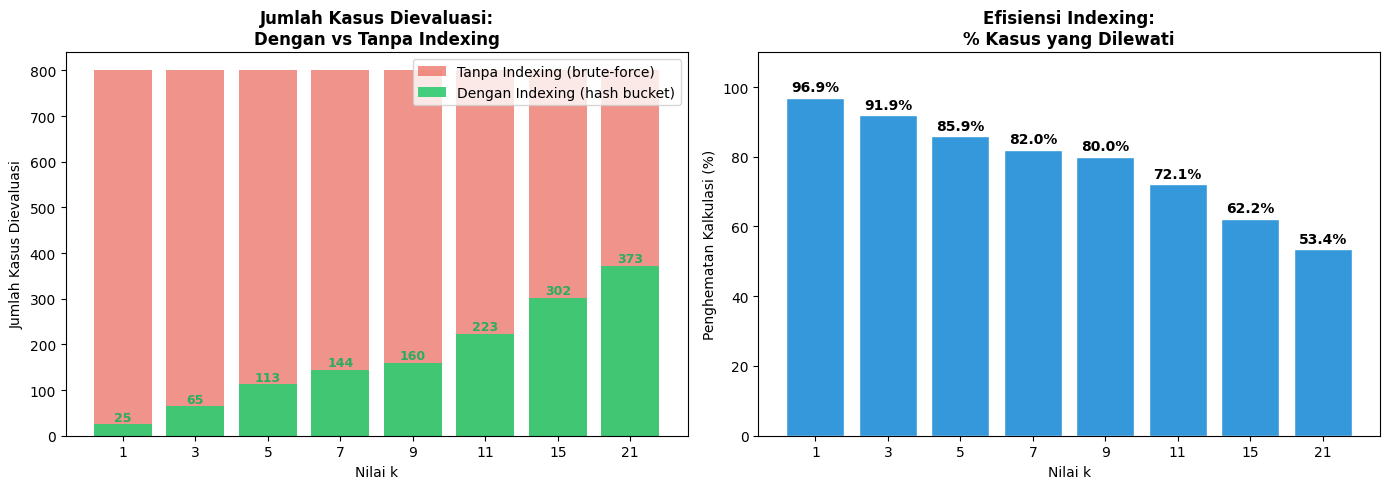

In [10]:
# -- Demonstrasi efisiensi indexing per nilai k ------------------------------
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
rows_eff  = []

for k in k_values:
    n_hits_k = []
    for _, q_raw in raw_test.iterrows():
        key = build_index_key(q_raw['disease_type'], q_raw['bmi'], q_raw['blood_pressure'])
        cands = hash_table.get(key, [])
        n_hits_k.append(len(cands) if len(cands) >= k else len(Xtr))
    avg = sum(n_hits_k) / len(n_hits_k)
    rows_eff.append({
        'k': k,
        'rata_kandidat': avg,
        'tanpa_index': len(Xtr),
        'penghematan_pct': (1 - avg / len(Xtr)) * 100
    })
    print(f'  k={k:2d}  | kandidat rata-rata: {avg:6.1f} / {len(Xtr)}  '
          f'| penghematan: {(1 - avg/len(Xtr))*100:.1f}%')

df_eff = pd.DataFrame(rows_eff)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: kandidat dievaluasi vs tanpa indexing
axes[0].bar(df_eff['k'].astype(str), df_eff['tanpa_index'],
            label='Tanpa Indexing (brute-force)', color='#e74c3c', alpha=0.6)
axes[0].bar(df_eff['k'].astype(str), df_eff['rata_kandidat'],
            label='Dengan Indexing (hash bucket)', color='#2ecc71', alpha=0.9)
axes[0].set_xlabel('Nilai k')
axes[0].set_ylabel('Jumlah Kasus Dievaluasi')
axes[0].set_title('Jumlah Kasus Dievaluasi:\nDengan vs Tanpa Indexing', fontweight='bold')
axes[0].legend()
for i, row in df_eff.iterrows():
    axes[0].text(i, row['rata_kandidat'] + 1, f"{row['rata_kandidat']:.0f}",
                 ha='center', va='bottom', fontsize=9, color='#27ae60', fontweight='bold')

# Chart 2: % penghematan kalkulasi jarak
bars2 = axes[1].bar(df_eff['k'].astype(str), df_eff['penghematan_pct'],
                    color='#3498db', edgecolor='white')
axes[1].set_xlabel('Nilai k')
axes[1].set_ylabel('Penghematan Kalkulasi (%)')
axes[1].set_title('Efisiensi Indexing:\n% Kasus yang Dilewati', fontweight='bold')
axes[1].set_ylim(0, 110)
for bar, row in zip(bars2, rows_eff):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{row['penghematan_pct']:.1f}%",
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()
